<a href="https://colab.research.google.com/github/ubaid978/Agentify/blob/main/TRANSFORMERS_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Classification with Transformer (Self-Study)

In this unit, we implement a transformer-based Sentiment Classifier for the NLTK movie reviews dataset.

## Dependencies

In [2]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0b446b3687fd05892f5db927b5fd6d0119125b926dfff26a34515eca0d07c63b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
import nltk, random
import numpy as np
from nltk.corpus import movie_reviews
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from lime.lime_text import LimeTextExplainer

In [4]:
## checking tf version
print(tf.__version__)

2.19.0


## Transformer Block

- A Transformer block consists of layers of Self Attention, Normalization, and feed-forward networks (i.e., MLP or Dense)).
- We use the `TransformerBlock` provided by `keras` (See keras official tutorial on [Text Classification with Transformer](https://keras.io/examples/nlp/text_classification_with_transformer/).
![](https://github.com/alvinntnu/NTNU_ENC2045_LECTURES/blob/main/images/transformer-block.svg?raw=1)
(<small>Source: [Transformers From Scratch](http://peterbloem.nl/blog/transformers)<small>)

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

def TransformerBlock(inputs, embed_dim, num_heads, ff_dim, rate=0.1):
    # 1️⃣ Multi-head Self Attention
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
    attn_output = layers.Dropout(rate)(attn_output)

    # 2️⃣ Add & Norm
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attn_output)

    # 3️⃣ Feed Forward Network
    ffn_output = layers.Dense(ff_dim, activation="relu")(out1)
    ffn_output = layers.Dense(embed_dim)(ffn_output)
    ffn_output = layers.Dropout(rate)(ffn_output)

    # 4️⃣ Add & Norm
    output = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

    return output
  # layer norm

## Embedding and Position

- And in Transformer-based networks, we need to include positional information of the tokens in the embeddings.
- Again, we use the `TokenAndPositionEmbedding` provided in `keras`'s tutorial.

In [6]:
from tensorflow import keras
from tensorflow.keras import layers
import keras_nlp

def TokenAndPositionEmbedding(inputs, maxlen, vocab_size, embed_dim):
    # 1️⃣ Token Embedding (standard Keras Embedding)
    x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)

    # 2️⃣ Prebuilt Position Embedding (from keras-nlp)
    x = keras_nlp.layers.PositionEmbedding(sequence_length=maxlen)(x)

    return x


In [9]:
import nltk
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

:::{note}
KerasNLP is an independent package developed for Keras 3+ that offers a comprehensive toolbox for natural language processing (NLP). It includes modular building blocks that range from pretrained state-of-the-art models to low-level components like Transformer Encoder layers.

In particular, the package includes modeling layers, such as TransformerEncoder, TransformerDecoder, TokenAndPositionEmbedding layers for various NLP tasks.

For more details, you can visit the [KerasNLP](https://keras.io/keras_nlp/) documentation.
:::

## Data

Now let us re-cap the important steps of data preparation for deep learning NLP:
- Texts in the corpus need to be randomized in order.
- Perform the data splitting of **training and testing** sets (sometimes, validation set).
- Build `tokenizer` using the training set.
- All the input texts need to be transformed into integer sequences.
- All the class labels need to be coded in **numeric integers**(as logits for `binary_crossentropy` or labels for `sparse_categorical_crossentropy`) or **one-hot encodings** (for `categorical_crossentropy` of the  multi-class labels).
- Determine the **vocabulary size** and the **maximum length** of the input sequences.
- **Padding** the input sequences to uniform lengths (i.e., the `max_len`).


### Preprocessing Steps

Procedures:
- Load the corpus texts (`nltk.corpus.movie_reviews`)
- Build the keras `tokenizer()`
- Fit the `tokenizer` on the corpus texts
- Convert the word sequences of texts into integer sentences with the `tokenizer`
- Pad input lengths to uniform sizes

In [10]:
## loading corpus
documents = [(' '.join(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
random.shuffle(documents)  #in-place shuffle

In [11]:
documents

[("the second serial - killer thriller of the month is just awful . oh , it starts deceptively okay , with a handful of intriguing characters and some solid location work . after a baby - sitter gets gutted in the suit - ably spooky someone ' s - in - the - house prologue , parallel stories unfold , the first involving a texas sheriff ( r . lee emery ) , a gruesome double murder , and the arrival of a morose fbi agent ( dennis quaid ) on the eve of voting for the local lawman ' s reelection . the second pairs a hitch - hiker ( jared leto ) with a friendly former railroad worker ( danny glover ) . they ' re headed west , toward the rockies and away from the murder scene . which one is the killer ? well , it doesn ' t really matter , ' cause when writer / first - time director jeb stuart ( die hard ) finally spills the beans , you won ' t take his choice seriously anyway . the whole thing goes south about an hour in , with the tale taking hairpin turns that i certainly couldn ' t follow 

In [12]:
print('Number of Reviews/Documents: {}'.format(len(documents)))
print('Sample Text of Doc 1:')
print('-' * 30)
print(documents[0][0][:50])  # first 50 words of the first document

Number of Reviews/Documents: 2000
Sample Text of Doc 1:
------------------------------
the second serial - killer thriller of the month i


In [13]:
## Train-Test Split
train_set, test_set = train_test_split(documents, test_size=0.1, random_state=42)

In [14]:
## Hyperparameters fot tokenizer
vocab_size = 10000
maxlen = 200  # Only consider the last 200 words of each movie review

## texts vs. labels
texts = np.array([t for (t, l) in train_set])
labels = np.array([1 if l == 'pos' else 0 for (t, l) in train_set])
## tokenizer
tokenizer = keras.preprocessing.text.Tokenizer(num_words=vocab_size)
## fit tokenizer
tokenizer.fit_on_texts(texts)
## text to sequences
texts_to_int = tokenizer.texts_to_sequences(texts)
## pad sequences
texts_to_int_pad = keras.preprocessing.sequence.pad_sequences(texts_to_int,
                                                              maxlen=maxlen,
                                                              truncating='pre',
                                                              padding='pre')

In [15]:
## X and y for train and val
x_train = texts_to_int_pad
y_train = labels


## Perform same vectorization on testing set
x_val_text = np.array([t for (t,l) in test_set])

x_val = keras.preprocessing.sequence.pad_sequences(
    tokenizer.texts_to_sequences(x_val_text),
    maxlen=maxlen,
    truncating='pre',
    padding='pre'
)

y_val = np.array([1 if l == 'pos' else 0 for (t, l) in test_set])


:::{tip}
It would be better if we can wrap the text vectorization into one functional call.
:::

In [16]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

(1800, 200)
(1800,)
(200, 200)
(200,)


In [17]:
# Check Total Vocab Size
total_vocab_size = len(tokenizer.word_index) + 1
print('Total Vocabulary Size (Untrimmed): %d' % total_vocab_size)
print('Vocabulary Size (trimmed): %d' % vocab_size)

Total Vocabulary Size (Untrimmed): 37634
Vocabulary Size (trimmed): 10000


## Define Classifier Architecture

- We then define the architecture of the network like before using `keras` Sequential or Functional API.
- The `TransformerBlock` and `TokenAndPositionEmbedding` function as like the other `keras.layers`.

In [18]:
embed_dim = 32  # Embedding size for each token
num_heads = 2  # Number of attention heads
ff_dim = 32  # Hidden layer size in feed forward network inside transformer

## Using Sequential API
from tensorflow import keras
from tensorflow.keras import layers
import keras_nlp


# Input
inputs = keras.Input(shape=(maxlen,))

# Embedding (token + position, prebuilt)
x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)
x = keras_nlp.layers.PositionEmbedding(sequence_length=maxlen)(x)

# Transformer block (from functional version we built earlier)
attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
attn_output = layers.Dropout(0.1)(attn_output)
out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
ffn_output = layers.Dense(ff_dim, activation="relu")(out1)
ffn_output = layers.Dense(embed_dim)(ffn_output)
ffn_output = layers.Dropout(0.1)(ffn_output)
x = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

# Output layer
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

# Build model
model = keras.Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 32)   │    320,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, 200, 32)   │      6,400 │ embedding[0][0]   │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 32)   │      8,416 │ position_embeddi… │
│ (MultiHeadAttentio… │                   │            │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 200, 32)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 200, 32)   │          0 │ position_embeddi… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 200, 32)   │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 200, 32)   │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 200, 32)   │      1,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 200, 32)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 200, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 32)   │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 337,089 (1.29 MB)

 Trainable params: 337,089 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from keras import Model
transformer=Model(inputs=inputs,outputs=outputs)

In [22]:
transformer.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 32)   │    320,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, 200, 32)   │      6,400 │ embedding[0][0]   │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 32)   │      8,416 │ position_embeddi… │
│ (MultiHeadAttentio… │                   │            │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 200, 32)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 200, 32)   │          0 │ position_embeddi… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 200, 32)   │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 200, 32)   │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 200, 32)   │      1,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 200, 32)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 200, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 32)   │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 337,089 (1.29 MB)

 Trainable params: 337,089 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [23]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x_train,
                    y_train,
                    batch_size=128,
                    epochs=2,
                    validation_data=(x_val, y_val))

Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['embedding/embeddings'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 459ms/step - accuracy: 0.5182 - loss: 0.7046 - val_accuracy: 0.4900 - val_loss: 0.6935
Epoch 2/2
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5090 - loss: 0.6939 - val_accuracy: 0.5100 - val_loss: 0.6932


## Ploting Training Results

In [24]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

matplotlib.rcParams['figure.dpi'] = 150


# Plotting results
def plot1(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)
    ## Accuracy plot
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    ## Loss plot
    plt.figure()

    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    plt.show()


def plot2(history):
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    #plt.gca().set_ylim(0,1)
    plt.show()

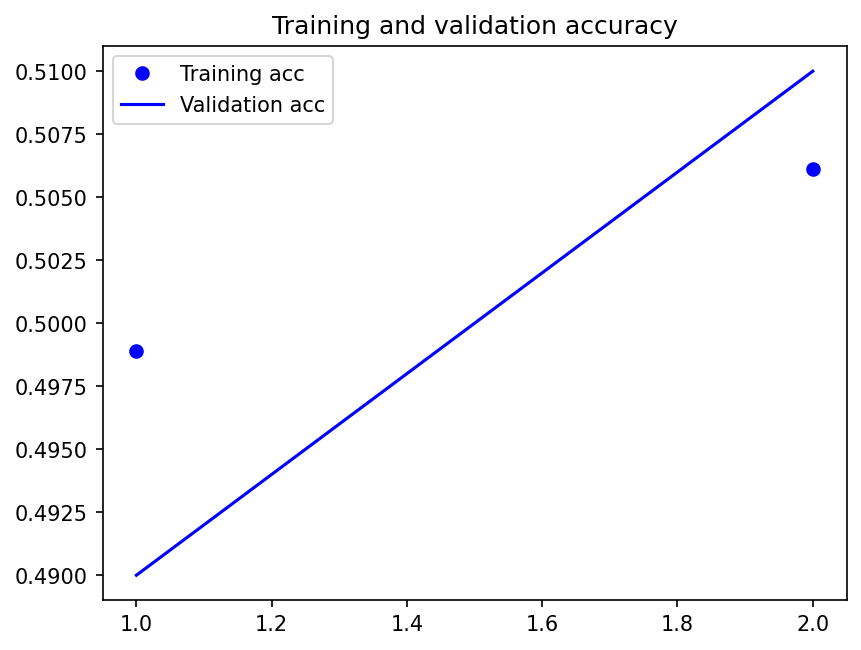

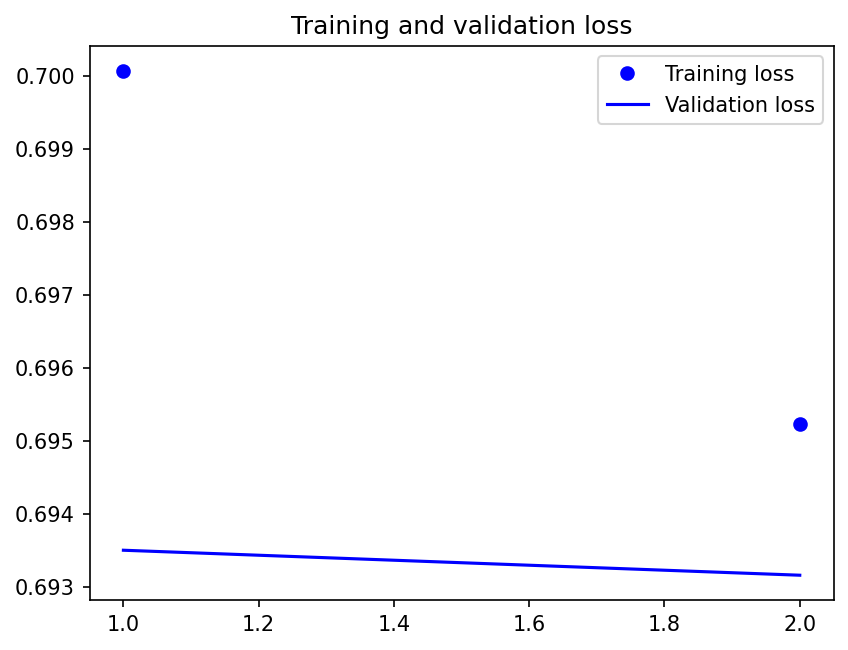

In [25]:
plot1(history)

- Given the small corpus size, it is clear to see that our model starts to overfit the training set quite a bit after the first few epochs (e.g, after the fourth epoch).
- In real application development, we may improve the model by:
    - increasing the datasets
    - increasing the embedding dimensions
    - using pre-trained embeddings
    - playing with the transformer blocks in terms of depths and widths of the layers
    - including dropouts, regularization, and normalization

## Explanation

In [26]:
explainer = LimeTextExplainer(class_names=["negative", "positive"])

In [27]:
def model_predict_pipeline(text):
    _seq = tokenizer.texts_to_sequences(text)
    _seq_pad = keras.preprocessing.sequence.pad_sequences(_seq, maxlen=maxlen)
    return np.array([[float(1 - x), float(x)]
                     for x in model.predict(np.array(_seq_pad))])
    #return model.predict(np.array(_seq_pad)) ## use this for logits

In [28]:
text_id = 123
model_predict_pipeline(x_val_text[[text_id]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/tmp/ipython-input-4177443332.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.array([[float(1 - x), float(x)]


array([[0.47975004, 0.52024996]])

In [29]:
## correct label
y_val[text_id]

np.int64(1)

In [30]:
exp = explainer.explain_instance(x_val_text[text_id],
                                 model_predict_pipeline,
                                 num_features=10,
                                 top_labels=1)

exp.show_in_notebook(text=True)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


/tmp/ipython-input-4177443332.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.array([[float(1 - x), float(x)]


## References

- This unit is based on the official keras tutorial: [Text classification with transfomer](https://keras.io/examples/nlp/text_classification_with_transformer/)
- Please read Peter Bloem's blog post on Transformers: [Transformers From Scratch](http://peterbloem.nl/blog/transformers). Highly recommended! Very comprehensive introduction of the attention mechanism and transformers.